In [9]:
import torch
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt

# Import necessary modules and classes
from MillerDataGen import MillerDataGenerator, DataGeneratorConfig

from MillerTest import MillerTestConfig, create_model
from MillerTrainer import MillerTrainer, TrainerConfig
import pickle

#### Choose the experiment parameters

In [10]:
N_INPUTS = 50 # Number of inputs
FEATURE_DIM = 30 # Number of latent dimensions
SEQUENCE_LEN = 3 # Number of items in the sim. test (includes probe)
SAVE = False
NUM_SAMPLES = 2000
BATCH_SIZE = 128 
INIT_SCALE = 2 # Initialization scale
N_EPOCHS = 500
data_path = "../training_histories/"

#### Create metric matrix


Circle

In [11]:
t = torch.linspace(0,1-1/N_INPUTS,N_INPUTS).unsqueeze(1)

METRIC_MATRIX = torch.zeros((N_INPUTS,N_INPUTS))
for i in range(N_INPUTS):
    for j in range(N_INPUTS):
        METRIC_MATRIX[i,j] = torch.min(torch.abs(t[i]-t[j]), 1-torch.abs(t[i]-t[j]))

Segment

In [12]:
t = torch.linspace(0,1,N_INPUTS).unsqueeze(1)
METRIC_MATRIX = torch.cdist(t,t)

___

### Train the toy model

In [13]:
histories = [] # List to store training histories
embss = [] # List to store embeddings
n_rep = 10 # Number of repetitions

seeds = [1,100,20,40,2,23,57,94,3,11]
for n in range(n_rep):
    print(f"Running repetition {n+1}/{n_rep}")
    # Create data generator
    genconf = DataGeneratorConfig()
    genconf.num_inputs = N_INPUTS
    genconf.batch_size = BATCH_SIZE
    genconf.num_samples = NUM_SAMPLES
    genconf.sequence_len = SEQUENCE_LEN
    genconf.metric_matrix = METRIC_MATRIX
    genconf.seed = seeds[n]

    genconf.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    gen = MillerDataGenerator(config = genconf)

    # Create model configuration
    model_config = MillerTestConfig(
                feature_dim=FEATURE_DIM,
                input_dim=genconf.num_inputs,
                sequence_len=genconf.sequence_len,
                init_scale = INIT_SCALE,
                activation = torch.nn.ReLU(),
                seed = seeds[n],
            )

    # Create training configuration
    tconf = TrainerConfig()
    tconf.losses = ["reconstruction","similarity"] # Choose the losses to use
    tconf.num_inputs = genconf.num_inputs 
    tconf.batch_size = BATCH_SIZE # Batch size
    tconf.num_epochs: int = N_EPOCHS # Number of epochs
    tconf.learning_rate: float = 7*1e-3 # Learning rate
    tconf.weight_decay: float = 0 # Weight decay
    tconf.patience = 700
    tconf.min_lr = 0
    tconf.lambda_rec = 0 # Weight of the reconstruction loss
    tconf.lambda_sim = .1 # Weight of the similarity loss

    model = create_model(model_config)
    # Initialize the model weights so that they are not orthogonal
    torch.nn.init.uniform_(model.embed.weight, a = 0*model_config.init_scale,b = model_config.init_scale)
    
    trainer = MillerTrainer(model, gen, tconf)

    history,embs = trainer.train(printevery = 500,compute_embeddings=True)
    histories.append(history)
    embss.append(embs)

Running repetition 1/10


AssertionError: Torch not compiled with CUDA enabled

In [14]:
f=plt.figure(figsize = (5,3))
plt.plot(history["similarity_losses"])

NameError: name 'history' is not defined

<Figure size 500x300 with 0 Axes>

In [ ]:
# Save histories and embss to a file
exp_name = f"experiment_segment_30dim_10rep"
with open(data_path + f'data_{exp_name}.pkl', 'wb') as f:
    pickle.dump({'histories': histories, 'embss': embss}, f)


### Load saved training results

In [ ]:
data_path = "../training_histories/"

In [ ]:
dic = pickle.load(open(data_path +'data_experiment_circleintrinsic_10dim_10rep.pkl', 'rb'))
histories = dic['histories']
embss = dic['embss']

dic = pickle.load(open(data_path +'data_experiment_segment_10dim_10rep.pkl', 'rb'))
histories_2 = dic['histories']
embss_2 = dic['embss']

dic = pickle.load(open(data_path +'data_experiment_purerec_10dim_10rep.pkl', 'rb'))
histories_3 = dic['histories']
embss_3 = dic['embss']


### Figure 4

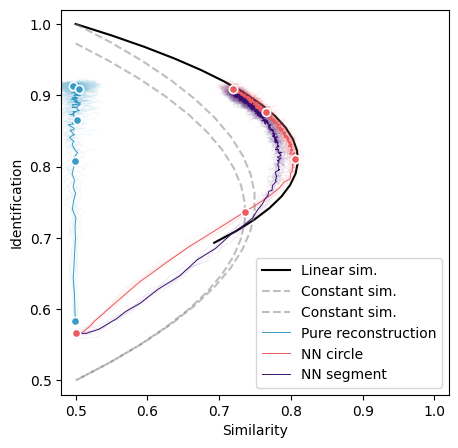

In [ ]:
n_rep = 10
tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (5,5))
c1 = plt.cm.magma(0.65)
c2 = plt.cm.magma(0.2)
c3 = plt.cm.GnBu(0.7)
Delta = 0.028
plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")
plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")
plt.plot(1/2 + (1-Delta)/(1+Delta)*(tspace - tspace**2), (2-(1-Delta)*tspace)/(2*(1+Delta)),color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")

mean_sim = np.mean(np.array([histories[i]["similarity_scores"] for i in range(n_rep)]),0)
mean_ident = np.mean(np.array([histories[i]["identification_scores"] for i in range(n_rep)]),0)
mean_sim_2 = np.mean(np.array([histories_2[i]["similarity_scores"] for i in range(n_rep)]),0)
mean_ident_2 = np.mean(np.array([histories_2[i]["identification_scores"] for i in range(n_rep)]),0)
mean_sim_3 = np.mean(np.array([histories_3[i]["similarity_scores"] for i in range(n_rep)]),0)
mean_ident_3 = np.mean(np.array([histories_3[i]["identification_scores"] for i in range(n_rep)]),0)

for i in range(n_rep):
        plt.plot(histories[i]['similarity_scores'],
        histories[i]['identification_scores'], 
        linewidth = 0.3, alpha = .1,
        color = c1)
for i in range(n_rep):
        plt.plot(histories_2[i]['similarity_scores'],
        histories_2[i]['identification_scores'], 
        linewidth = 0.3, alpha = .1,
        color = c2)
for i in range(n_rep):
        plt.plot(histories_3[i]['similarity_scores'],
        histories_3[i]['identification_scores'], 
        linewidth = 0.3, alpha = .1,
        color = c3)


sas = [0,17,35,160,499]
#sas = [0,5,17,499]
plt.plot(mean_sim_3,mean_ident_3,color=c3, label = "Pure reconstruction",linewidth = 0.7)
plt.plot(mean_sim,mean_ident,color=c1, label = "NN circle",linewidth = 0.7)
plt.plot(mean_sim_2,mean_ident_2,color=c2, label = "NN segment",linewidth = 0.7)

sc= plt.scatter(mean_sim_3[sas],mean_ident_3[sas],color = c3, zorder = 10)
sc.set_edgecolors('white')
sc.set_linewidths(1.2)

sc= plt.scatter(mean_sim[sas],mean_ident[sas],color = c1, zorder = 10)
sc.set_edgecolors('white')
sc.set_linewidths(1.2)

plt.xlim([0.48,1.02])
plt.ylim([0.48,1.02])
plt.xticks([0.5,0.6,0.7,0.8,0.9,1])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend()


### Display learned similarity functions

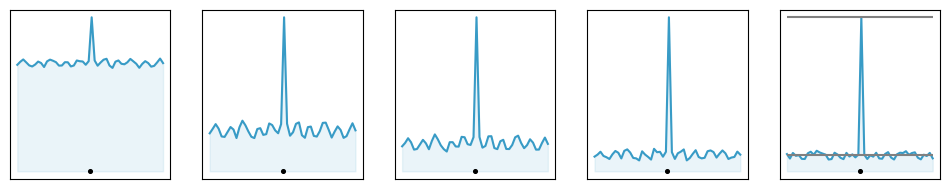

In [ ]:
xx = np.linspace(0,1,N_INPUTS)
sas = [0,17,35,160,499]

N = len(sas)

f = plt.figure(figsize = (12,2.2))
ids = 25
for i in range(N):
    ax = plt.subplot(1,N,i+1)
    #S = np.mean(np.array([embss_3[j][sas[i]]@embss_3[j][sas[i]].T for j in range(n_rep)]),0)
    S = embss_3[0][sas[i]]@embss_3[0][sas[i]].T
    S= np.maximum(S,0)
    g = np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0)
    ax.plot(xx,g, color = c3)
    ax.fill_between(xx,0,np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0), alpha = 0.1,color = c3)
    ax.scatter(x=ids/50,y=0, color = "k", s=7)
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_ylim([-0.6,18])
a = np.mean([g[i] for i in range(len(g)) if i != 25])
b = np.max(g)
ax.hlines(b,0,1, color = "gray")
ax.hlines(a,0,1, color = "gray")


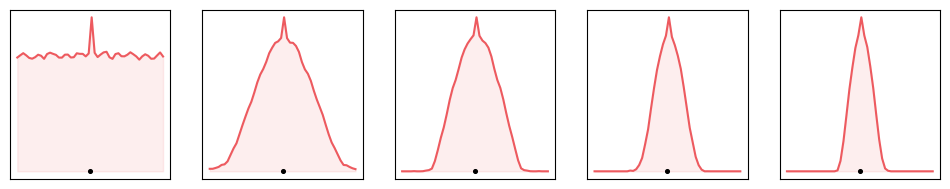

In [ ]:
xx = np.linspace(0,1,N_INPUTS)
sas = [0,17,35,160,499]

N = len(sas)

f = plt.figure(figsize = (12,2.2))
ids = 25
for i in range(N):
    ax = plt.subplot(1,N,i+1)
    S = embss[0][sas[i]]@embss[0][sas[i]].T
    S= np.maximum(S,0)
    ax.plot(xx,np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0), color = c1)
    ax.fill_between(xx,0,np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0), alpha = 0.1,color = c1)
    ax.scatter(x=ids/50,y=0, color = "k", s=7)
    ax.set_xticks([])
    ax.set_yticks([])


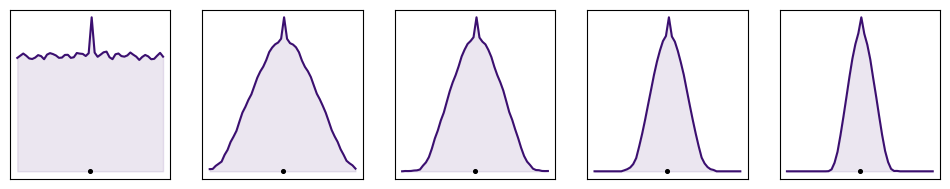

In [ ]:
xx = np.linspace(0,1,N_INPUTS)
sas = [0,17,35,160,499]

N = len(sas)

f = plt.figure(figsize = (12,2.2))
ids = 25
for i in range(N):
    ax = plt.subplot(1,N,i+1)
    S = embss_2[0][sas[i]]@embss_2[0][sas[i]].T
    S= np.maximum(S,0)
    ax.plot(xx,np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0), color = c2)
    ax.fill_between(xx,0,np.mean([np.roll(S[i,:],-i+ids) for i in range(1,S.shape[0]-1)],0), alpha = 0.1,color = c2)
    ax.scatter(x=ids/50,y=0, color = "k", s=7)
    ax.set_xticks([])
    ax.set_yticks([])


In [18]:
# Compositional extensions: imports
from MillerDataGen import CompositionalDataGeneratorConfig, CompositionalDataGenerator
from MillerTest import CompositionalModelConfig, create_compositional_model


In [19]:
# Two-slot (two circles) metric setup
S1 = 24
S2 = 24
seq_len = 3
BATCH_SIZE = 128
NUM_SAMPLES = 2000
FEATURE_DIM = 32
INIT_SCALE = 1.0

# Build two circular distance matrices

t1 = torch.linspace(0, 1 - 1/S1, S1).unsqueeze(1)
D1 = torch.zeros((S1, S1))
for i in range(S1):
    for j in range(S1):
        D1[i, j] = torch.min(torch.abs(t1[i]-t1[j]), 1-torch.abs(t1[i]-t1[j]))


t2 = torch.linspace(0, 1 - 1/S2, S2).unsqueeze(1)
D2 = torch.zeros((S2, S2))
for i in range(S2):
    for j in range(S2):
        D2[i, j] = torch.min(torch.abs(t2[i]-t2[j]), 1-torch.abs(t2[i]-t2[j]))


In [20]:
# Build compositional generator (max-over-slot decision)
comp_conf = CompositionalDataGeneratorConfig(
    num_slots=2,
    vocab_sizes=(S1, S2),
    sequence_len=seq_len,
    batch_size=BATCH_SIZE,
    slot_metric_matrices=(D1, D2),
    seed=1,
    num_samples=NUM_SAMPLES,
)
comp_gen = CompositionalDataGenerator(comp_conf)

# Build compositional model
comp_model_conf = CompositionalModelConfig(
    input_dim=S1 + S2,
    feature_dim=FEATURE_DIM,
    sequence_len=seq_len,
    vocab_sizes=(S1, S2),
    activation=torch.nn.ReLU(),
)
comp_model = create_compositional_model(comp_model_conf)

# Initialize weights
for layer in comp_model.slot_embedders:
    torch.nn.init.uniform_(layer.weight, a=0.0, b=INIT_SCALE)

# Trainer config (same losses; lambda_sim drives learning)
comp_tconf = TrainerConfig()
comp_tconf.losses = ["reconstruction", "similarity"]
comp_tconf.num_inputs = S1 + S2
comp_tconf.batch_size = BATCH_SIZE
comp_tconf.num_epochs = 300
comp_tconf.learning_rate = 7e-3
comp_tconf.weight_decay = 0.0
comp_tconf.patience = 700
comp_tconf.min_lr = 0
comp_tconf.lambda_rec = 0.0
comp_tconf.lambda_sim = 0.1

comp_trainer = MillerTrainer(comp_model, comp_gen, comp_tconf)
comp_history = comp_trainer.train(printevery=50)


IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)